### `bias_spectroscopic`
------------------------

Short notebook to provide insights on propagated error measurements for bias fits.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib

from scipy.optimize import curve_fit
from pathlib import Path

import src.analysis.plots as plots
import src.statistics.corrfiles as cf

tracers = ["BGS_BRIGHT-21.35", "LRG", "ELGnotqso", "ELG_LOPnotqso", "QSO"]
cmap = plt.get_cmap("plasma")
tracer_to_color = {
    tracer: cmap((i + 1) / (len(tracers) + 1)) for i, tracer in enumerate(tracers)
}

DESI_ROOT_DR2 = Path(
    "/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/nonKP"
)
PAPER_FIGURES_ROOT = Path(
    "/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/"
)

pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

dir_bias = Path(cf.get_base_dir()) / "data" / "bias"
files = {tracer: dir_bias / f"{tracer}_bias.txt" for tracer in tracers}


def load_bias_file(file):
    data = np.loadtxt(file, comments="#")
    return {
        "zmin": data[:, 0],
        "zmax": data[:, 1],
        "zeff": data[:, 2],
        "b": data[:, 3],
        "b_err": data[:, 4],
    }


def bias(z, a, b):
    """
    Laurent et al. 2017 functional form
    We do not include the -6.565 factor since we fit for a and b
    and one can always reformulate a, b to include it.
    """
    return a * (1 + z) ** 2 + b

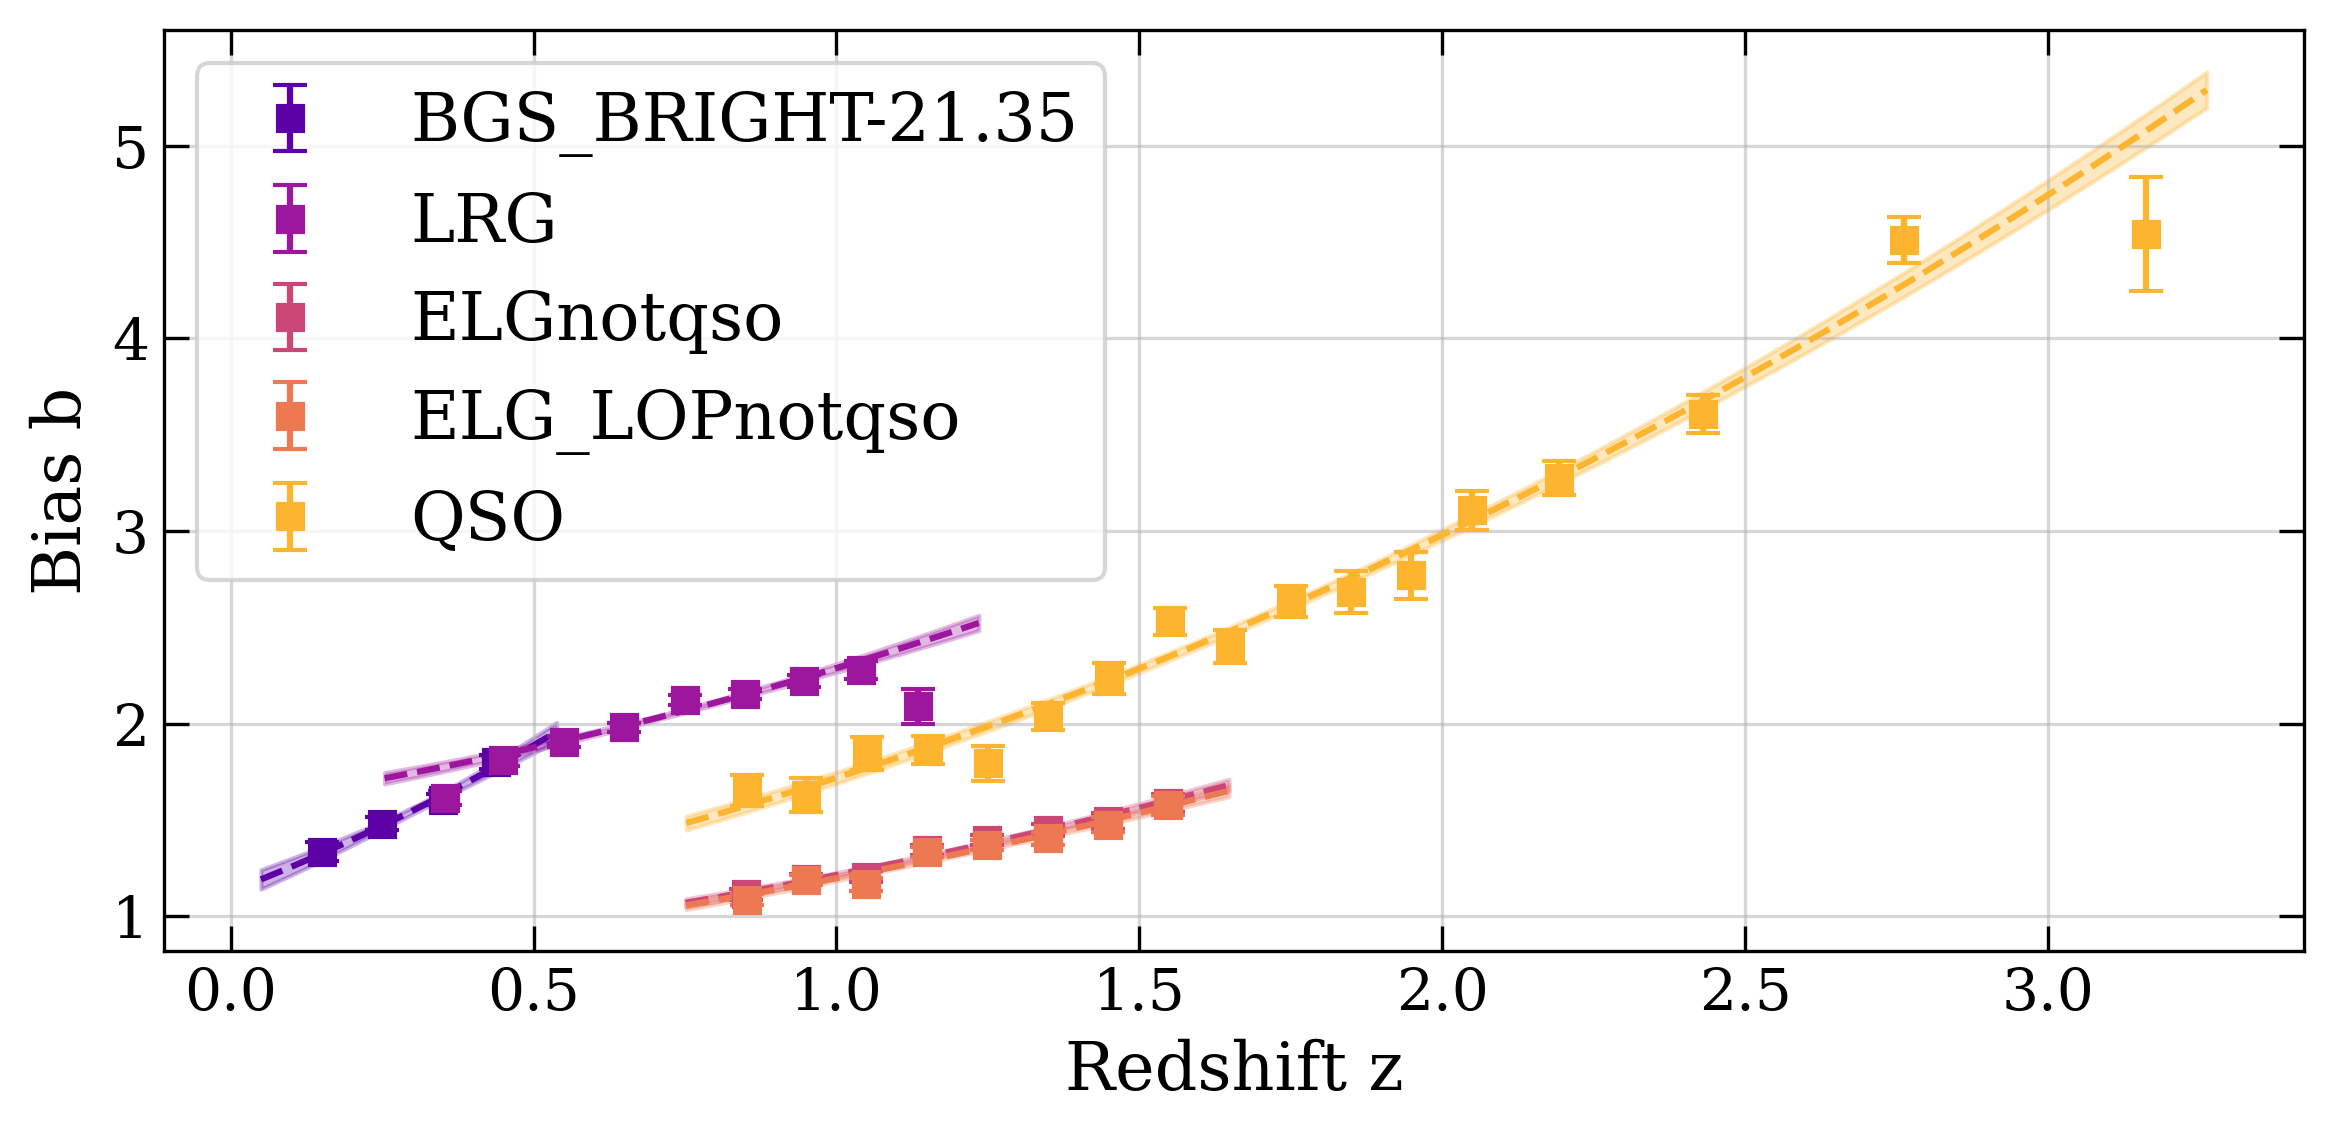

In [3]:
with pm.make_plot("bias_spectroscopic", show=True, figsize=(8, 4)) as (fig, ax):
    for tracer in tracers:
        bias_data = load_bias_file(files[tracer])
        ax.errorbar(
            x=bias_data["zeff"],
            y=bias_data["b"],
            yerr=bias_data["b_err"],
            label=tracer,
            color=tracer_to_color[tracer],
            marker="s",
            linestyle="None",
            capsize=4,
        )

        if tracer == "LRG":
            mask = (bias_data["zeff"] > 0.4) & (bias_data["zeff"] < 1.1)
        else:
            mask = np.ones_like(bias_data["zeff"], dtype=bool)

        bias_zeff = bias_data["zeff"][mask]
        bias_b = bias_data["b"][mask]
        bias_b_err = bias_data["b_err"][mask]

        popt, pcov = curve_fit(
            bias, bias_zeff, bias_b, sigma=bias_b_err, absolute_sigma=True
        )
        perr = np.sqrt(np.diag(pcov))
        residuals = bias_b - bias(bias_zeff, *popt)
        chi2 = np.sum((residuals / bias_b_err) ** 2)
        ndof = len(bias_zeff) - len(popt)
        chi2_red = chi2 / ndof

        z_fit = np.linspace(
            min(bias_data["zeff"]) - 0.1, max(bias_data["zeff"]) + 0.1, 100
        )
        b_fit = bias(z_fit, *popt)

        J = np.column_stack([(1 + z_fit) ** 2, np.ones_like(z_fit)])
        b_fit_var = np.einsum("ij,jk,ik->i", J, pcov, J)
        b_fit_err_analytical = np.sqrt(b_fit_var)

        ax.plot(z_fit, b_fit, color=tracer_to_color[tracer], linestyle="--")

        ax.fill_between(
            z_fit,
            b_fit - b_fit_err_analytical,
            b_fit + b_fit_err_analytical,
            color=tracer_to_color[tracer],
            alpha=0.3,
        )

    ax.grid(True)
    ax.set_xlabel("Redshift z", fontsize=16)
    ax.set_ylabel("Bias b", fontsize=16)
    ax.legend(loc="upper left", fontsize=16)